In [1]:
'''
ML Pipeline for Gridded Precip Project (XGBoost)

Overview and Motivation
The goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework 
for predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time, 
we adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.

1. Gridded surface preprocessing
All predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.
Output: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.

2. Precip phase labeling via MRoS proxy
The interpolated MRoS proxy surface is converted into discrete phase classes:
The MRoS proxy is used exclusively for labeling and is not included as a predictor to avoid target leakage.
Output: A space-time mask identifying gridcell-hours with usable phase labels.

3. Feature table construction: 
Transform gridded data back into tabular format required for ML processing
Output: a tabular dataset (e.g., parquet) suitable for ML training

4. Spatial blocking to split data
Motivation: spatial blocking accounts for spatial autocorrelation and avoids overestimated performance that arise from random splits.

5. ML model training
XGBoost multiclass classifier: 
Target: predict rain, mix, or snow probabilities
Outputs class probabilities (& uncertainty)
Model hyperparameter tuning on validation set
tree depth, learning rate, subsampling, min_child_weight, etc.
stopping criteria via early stopping on validation loss

6. Model evaluation and performance
Model performance is evaluated on a fully held-out test set.
Accuracy / Macro F1 (for balanced class performance)
RMSE or MAE if numeric encoding used for rain/mix/snow
Brier Score (probabilistic accuracy)
Bias / Confusion matrices
Stratify results:
By elevation band (e.g., <1500 m, 1500–2500 m, >2500 m)
By station density or IMEGR PLP intensity

7. Model interpretation
Goal: Understand what drives predictions
Compute SHAP values for each feature → shows its contribution to each class probability.

'''


'\nML Pipeline for Gridded Precip Project (XGBoost)\n\nOverview and Motivation\nThe goal of this workflow is to integrate heterogeneous observational, satellite, and climatological datasets into a unified, physically informed ML framework \nfor predicting precipitation phase (rain, snow, or mixed). Because direct precipitation-phase observations are sparse and unevenly distributed in space and time, \nwe adopt a weakly supervised labeling approach using an interpolated MRoS proxy, combined with spatially blocked ML training to handle prediction across complex terrain.\n\n1. Gridded surface preprocessing\nAll predictor layers are aligned to a common coordinate reference system, grid resolution, and timestamp index.\nOutput: Stacked gridded predictor datasets (NetCDF), one layer per variable per hour.\n\n2. Precip phase labeling via MRoS proxy\nThe interpolated MRoS proxy surface is converted into discrete phase classes:\nThe MRoS proxy is used exclusively for labeling and is not include

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

In [3]:
DATA_DIR = Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data")

PATHS = {
    "IDW": DATA_DIR / "IDW/hourly_predictors_1km_IDW_full.nc",
    "imerg": DATA_DIR / "resampled_grids/imerg_hourly_1km.nc",
    "prism": DATA_DIR / "resampled_grids/prism_hourly_1km.nc",
}


## Step  1: Input Dataset QAQC Checks and Preprocessing

In [4]:
## Checking time synchroniziation -------------------------------------------------

ds_IDW = xr.open_dataset(PATHS["IDW"])
ds_imerg = xr.open_dataset(PATHS["imerg"])
ds_prism = xr.open_dataset(PATHS["prism"])

for name, ds in {
    "IDW": ds_IDW,
    "IMERG": ds_imerg,
    "PRISM": ds_prism,
}.items():
    print(f"\n{name}")
    print(ds)

def summarize_time(ds, name):
    t = ds["time"]
    print(f"\n{name} time summary:")
    print("  start:", pd.to_datetime(t.values[0]))
    print("  end:  ", pd.to_datetime(t.values[-1]))
    print("  n:", t.size)
    print("  freq guess:", pd.infer_freq(pd.to_datetime(t.values[:10])))

summarize_time(ds_IDW, "IDW")
summarize_time(ds_imerg, "IMERG")
summarize_time(ds_prism, "PRISM")


IDW
<xarray.Dataset> Size: 5GB
Dimensions:         (time: 5832, y: 251, x: 142)
Coordinates:
  * y               (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x               (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time            (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:0...
Data variables:
    temp_air        (time, y, x) float32 831MB ...
    temp_dew        (time, y, x) float32 831MB ...
    temp_wet        (time, y, x) float32 831MB ...
    rh              (time, y, x) float32 831MB ...
    mros_plp_proxy  (time, y, x) float32 831MB ...
    plp             (time, y, x) float32 831MB ...
    elev            (y, x) float32 143kB ...
    spatial_ref     int64 8B ...
Attributes:
    title:             Hourly predictor stacks on 1-km grid
    lapse_degC_per_m:  -0.005
    idw_power:         2.0
    k_nearest:         8
    GeoTransform:      162130.9182594687 1000.0 0.0 4426426.168783374 0.0 -10...

IMERG
<xarray.Dataset> Size: 

In [5]:
common_times = np.intersect1d(
    ds_IDW.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(
    common_times,
    ds_prism.time.values
)

print("Common timesteps:", len(common_times))

Common timesteps: 5160


In [6]:
ds_IDW = ds_IDW.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

In [7]:
## Checking grud synchroniziation -------------------------------------------------

def summarize_grid(ds, name):
    print(f"\n{name} grid:")
    for dim in ["x", "y"]:
        if dim in ds.dims:
            vals = ds[dim].values
            print(f"  {dim}: n={len(vals)}, "
                  f"min={vals.min():.2f}, max={vals.max():.2f}, "
                  f"dx≈{np.mean(np.diff(vals)):.2f}")

summarize_grid(ds_IDW, "IDW")
summarize_grid(ds_imerg, "IMERG")
summarize_grid(ds_prism, "PRISM")



IDW grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

IMERG grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00

PRISM grid:
  x: n=142, min=162630.92, max=303630.92, dx≈1000.00
  y: n=251, min=4175926.17, max=4425926.17, dx≈-1000.00


In [8]:
## Checking general stats -------------------------------------------------

def quick_stats(ds, var):
    v = ds[var]
    return {
        "min": float(v.min()),
        "max": float(v.max()),
        "nan_frac": float(v.isnull().mean())
    }

for var in ds_prism.data_vars:
    print("PRISM", var, quick_stats(ds_prism, var))


PRISM prism_tair {'min': -26.73922626164204, 'max': 34.437614700831105, 'nan_frac': 0.0}
PRISM prism_tmean {'min': -16.262734494423775, 'max': 25.713881844107153, 'nan_frac': 0.0}
PRISM prism_tdmean {'min': -28.220525136197175, 'max': 15.807606480060583, 'nan_frac': 0.0}
PRISM prism_ppt_daily {'min': 0.0, 'max': 179.0049390438019, 'nan_frac': 0.0}
PRISM spatial_ref {'min': 0.0, 'max': 0.0, 'nan_frac': 0.0}


In [9]:
## Checking internal time counts/distribution -------------------------------------------------


def time_qc(ds, name):
    t = pd.to_datetime(ds.time.values)
    print(f"\n{name} time QC:")
    print("  monotonic:", (np.diff(t.values) > np.timedelta64(0, "s")).all())
    print("  unique:", len(t) == len(np.unique(t)))
    # Check that all are on the hour
    print("  all on hour:", np.all(t.minute == 0) and np.all(t.second == 0))

    # Check per-day counts
    per_day_counts = pd.Series(1, index=t).resample("D").sum()
    print("  per-day count summary:")
    print(per_day_counts.describe())

time_qc(ds_IDW, "IDW")
time_qc(ds_imerg, "IMERG")
time_qc(ds_prism, "PRISM")



IDW time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64

IMERG time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64

PRISM time QC:
  monotonic: True
  unique: True
  all on hour: True
  per-day count summary:
count    232.000000
mean      22.241379
std        6.267653
min        0.000000
25%       24.000000
50%       24.000000
75%       24.000000
max       24.000000
dtype: float64


In [10]:
## Checking somre more stats -------------------------------------------------

def var_stats(ds, vars_, name):
    print(f"\n{name} value stats:")
    for v in vars_:
        da = ds[v]
        print(
            f"  {v}: "
            f"min={float(da.min()):.2f}, "
            f"max={float(da.max()):.2f}, "
            f"nan_frac={float(da.isnull().mean()):.4f}"
        )

var_stats(
    ds_IDW,
    ["temp_air", "temp_dew", "temp_wet", "rh", "mros_plp_proxy", "plp"],
    "IDW"
)

var_stats(ds_imerg, ["imerg_plp"], "IMERG")

var_stats(
    ds_prism,
    ["prism_tair", "prism_tmean", "prism_tdmean", "prism_ppt_daily"],
    "PRISM"
)



IDW value stats:
  temp_air: min=-36.99, max=55.30, nan_frac=0.0000
  temp_dew: min=-39.48, max=21.13, nan_frac=0.0000
  temp_wet: min=-38.45, max=42.84, nan_frac=0.0000
  rh: min=2.03, max=100.00, nan_frac=0.0000
  mros_plp_proxy: min=0.00, max=100.00, nan_frac=0.8665
  plp: min=0.00, max=100.00, nan_frac=0.0000

IMERG value stats:
  imerg_plp: min=0.00, max=100.00, nan_frac=0.0000

PRISM value stats:
  prism_tair: min=-26.74, max=34.44, nan_frac=0.0000
  prism_tmean: min=-16.26, max=25.71, nan_frac=0.0000
  prism_tdmean: min=-28.22, max=15.81, nan_frac=0.0000
  prism_ppt_daily: min=0.00, max=179.00, nan_frac=0.0000


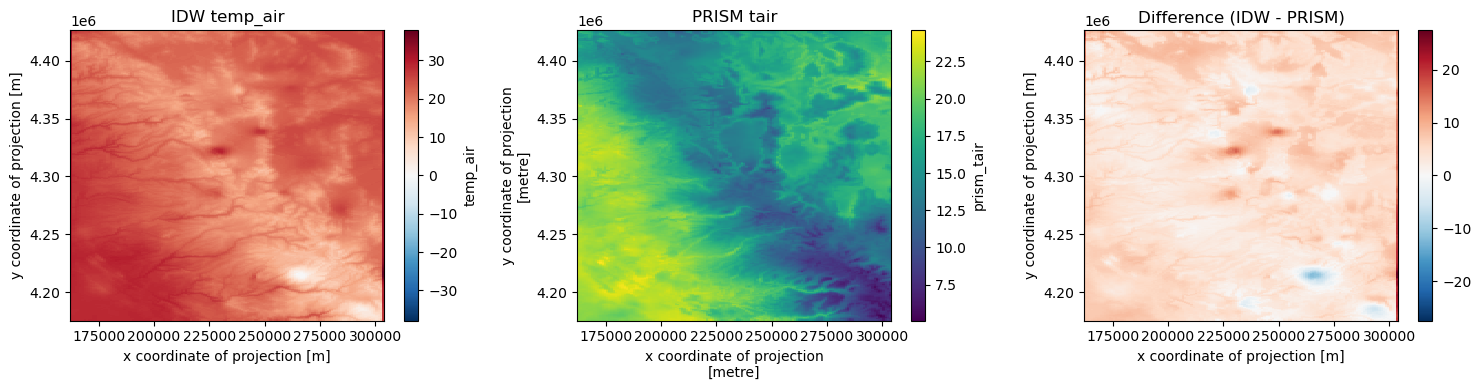

In [11]:
## Visualize timestep -------------------------------------------------

# IDW station t_air vs PRISM t_air
t0 = ds_imerg.time.values[0]

idw_t = ds_IDW["temp_air"].sel(time=t0)
prism_t = ds_prism["prism_tair"].sel(time=t0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
idw_t.plot(ax=axes[0])
axes[0].set_title("IDW temp_air")

prism_t.plot(ax=axes[1])
axes[1].set_title("PRISM tair")

(idw_t - prism_t).plot(ax=axes[2])
axes[2].set_title("Difference (IDW - PRISM)")

plt.tight_layout()


In [12]:
# Finally intersect times and commit to common period

common_times = np.intersect1d(
    ds_IDW.time.values,
    ds_imerg.time.values
)
common_times = np.intersect1d(common_times, ds_prism.time.values)

ds_IDW   = ds_IDW.sel(time=common_times)
ds_imerg = ds_imerg.sel(time=common_times)
ds_prism = ds_prism.sel(time=common_times)

assert ds_IDW.time.identical(ds_imerg.time)
assert ds_IDW.time.identical(ds_prism.time)


In [13]:
# Build one xarray dataset containing only the predictors

predictors = xr.Dataset(
    {
        # IDW / kriging
        "temp_air": ds_IDW["temp_air"],
        "temp_dew": ds_IDW["temp_dew"],
        "temp_wet": ds_IDW["temp_wet"],
        "rh": ds_IDW["rh"],

        # IMERG
        "imerg_plp": ds_imerg["imerg_plp"],

        # PRISM
        "prism_tair": ds_prism["prism_tair"],
        "prism_tmean": ds_prism["prism_tmean"],
        "prism_tdmean": ds_prism["prism_tdmean"],
        "prism_ppt_daily": ds_prism["prism_ppt_daily"],

        # Static
        "elev": ds_IDW["elev"],
    },
    coords={
        "time": ds_IDW.time,
        "x": ds_IDW.x,
        "y": ds_IDW.y,
    }
)
print(predictors)

SETUP_DIR = DATA_DIR / "compiled_input_predictors"
SETUP_DIR.mkdir(exist_ok=True)

predictors.to_netcdf(
    SETUP_DIR / "predictors_hourly_1km_withIDW.nc",
    # SETUP_DIR / "predictors_hourly_1km_withKrigingVX.nc",
    encoding={v: {"zlib": True, "complevel": 4} for v in predictors.data_vars}
)

print("Saved input predictor stack")


<xarray.Dataset> Size: 10GB
Dimensions:          (y: 251, x: 142, time: 5160)
Coordinates:
  * y                (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x                (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time             (time) datetime64[ns] 41kB 2024-10-11 ... 2025-05-30T23:...
Data variables:
    temp_air         (time, y, x) float32 736MB 34.84 34.76 ... 22.86 37.85
    temp_dew         (time, y, x) float32 736MB 7.836 7.82 ... -6.145 8.821
    temp_wet         (time, y, x) float32 736MB 21.32 21.3 21.24 ... 9.009 24.0
    rh               (time, y, x) float32 736MB 18.07 18.16 ... 14.49 14.48
    imerg_plp        (time, y, x) float64 1GB 100.0 100.0 100.0 ... 100.0 100.0
    prism_tair       (time, y, x) float64 1GB 17.53 17.01 15.26 ... 12.2 11.56
    prism_tmean      (time, y, x) float64 1GB 17.53 17.01 15.26 ... 10.64 10.13
    prism_tdmean     (time, y, x) float64 1GB 0.06757 0.2061 ... -3.137 -3.337
    prism_ppt_daily  (ti

## Step 2: Labeling and confidence masking

In [ ]:
# Define phase thresholds

# def classify_phase(proxy):
#     return xr.where(
#         proxy >= 0.75, 2,          # rain
#         xr.where(proxy <= 0.25, 0,  # snow
#                  1)                # mix
#     )

phase = xr.where(
    ds_IDW["mros_plp_proxy"] == 100, 2,
    xr.where(ds_IDW["mros_plp_proxy"] == 0, 0, 1)
)

# Create mask to enfornce valid samples... 
# Not all gridcell hours are reliable from MRoS proxy (it's not actually ground truth, some estimates may be low confidence) 
# or IMERG (many hours are non-precipitating).
label_mask = (
    ds_IDW["mros_plp_proxy"].notnull() &
    (ds_imerg["imerg_plp"] > 0.05)
)

labels = xr.Dataset(
    {
        "phase": phase,
        "label_mask": label_mask,
    },
    coords=predictors.coords
)

labels.to_netcdf(
    SETUP_DIR / "labels_phase_hourly_1km.nc",
    encoding={"phase": {"zlib": True}, "label_mask": {"zlib": True}}
)


## Step 3: Gridded to tabular extraction + spatial blocking

In [20]:
# Parquets will be much faster to use in ML... convert aligned gridded predictors + labels into a single, analysis-ready tabular dataset, apply label masking, assign spatial blocks, and write to Parquet once.

# SETUP_DIR = DATA_DIR / "compiled_input_predictors"
# predictors = xr.open_dataset(SETUP_DIR / "predictors_hourly_1km.nc")
# labels     = xr.open_dataset(SETUP_DIR / "labels_phase_hourly_1km.nc")

# Check label mask
label_mask = labels["label_mask"]

mask_frac = float(label_mask.mean())
print(f"Fraction of gridcell-hours kept: {mask_frac:.3f}")

Fraction of gridcell-hours kept: 0.131


Output mask_frac comes out to 0.131.. (13.1% is appropriate based on literature; reflects spatial sparsity of precip and intermittency of storms).

When multiplied by 184 million possible gridcell hours (5160 hrs x 251x142 cells ~= 184 mill) 
--> ~24 million samples (sufficient for ML).
Precip is rare in space and time, since most gridcells are dry most of the time, and even during storms precip is spatially patchy.
MRoS proxy is also sparse by design (crowd-sourced, opportunistic, spatially unevenm biased towards population centers), so we want to exclude unlabeled areas and low-confidence proxy estimates

In [ ]:
# Reshaping/stacking to convert each (time, x, y) gridcell into one ML sample

predictors_stacked = predictors.stack(sample=("time", "y", "x"))
labels_stacked     = labels.stack(sample=("time", "y", "x"))
mask_stacked       = label_mask.stack(sample=("time", "y", "x"))

# Apply confidence mask after stacking to remove entire samples that fail label validity criteria. 
# This helps ensure that every retained sample has a usable phase label... a
# Aso reduces dataset size to enhance label quality.
predictors_valid = predictors_stacked.where(mask_stacked, drop=True)
labels_valid     = labels_stacked.where(mask_stacked, drop=True)


# At this point:
# - every remaining row has a valid phase label
# - no NaN label rows survive

# Up until this point, xarray was useful because it enforced coordinate alignment, supported label dimensions, etc... but ML libraries will require 2D tabular inputs.
# So, we convert to pandas:

# Convert to pandas
X = predictors_valid.to_dataframe()
y = labels_valid[["phase"]].to_dataframe()[["phase"]] # phase target is kept separately to prevent leakage

# Identify index names (these will be inserted by reset_index) and enforce uniqueness prior to flattening
index_cols = X.index.names  # typically ['time', 'y', 'x']

df = (
    X.drop(columns=index_cols, errors="ignore")
     .join(y, how="inner")
     .reset_index()
)

print(df.columns)

assert df.columns.duplicated().sum() == 0

# Now each row is a single gridcell at a single hour.
# Predictor columns
# Target phase column
# Spatiotemporal metadata columns (x, y, time)


Index(['time', 'y', 'x', 'temp_air', 'temp_dew', 'temp_wet', 'rh', 'imerg_plp',
       'prism_tair', 'prism_tmean', 'prism_tdmean', 'prism_ppt_daily', 'elev',
       'phase'],
      dtype='object')


In [ ]:
# Check class balance (by phase)
df["phase"].value_counts(normalize=True)

phase
1.0    0.623923
2.0    0.200047
0.0    0.176030
Name: proportion, dtype: float64

In [ ]:
# Temporal coverage (by month)
df.groupby(df["time"].dt.month)["phase"].count()

time
1     1868147
2     5409812
3     3545118
4     2070457
5     1211828
10     819766
11    4637225
12    4477986
Name: phase, dtype: int64

In [27]:
# Spatial coverage
df.groupby(["x", "y"]).size().describe()

count    35642.000000
mean       674.494669
std         24.108310
min        504.000000
25%        673.000000
50%        683.000000
75%        689.000000
max        689.000000
dtype: float64

## Step 4: Spatial Blocking
### 4a: Defining spatial blocks
Motivation: Standard random cross-validation grossly overestimates ML skill when data are spatially autocorrelated.
Guiding literature: Stock & Subramaniam (2022); https://doi.org/10.1080/15481603.2022.2107113
- Random splits allow near-duplicate information to leak across train/test
- Reported accuracy becomes meaningless for true spatial generalization

In our case, neighboring gridcells share:
- elevation
- meteorology
- storm structure
Random CV would dramatically overestimate phase-prediction skill

In [31]:
# OUT_DIR = DATA_DIR / "parquet"
# OUT_DIR.mkdir(exist_ok=True)

# OUT_PATH = OUT_DIR / "ml_table_hourly_1km.parquet"

# df.to_parquet(
#     OUT_PATH,
#     engine="pyarrow",
#     compression="snappy",
#     index=False,
# )

# Each row = one labeled gridcell-hour
# predictors:
    # temp_air, temp_dew, temp_wet, rh,
    # imerg_plp,
    # prism_tair, prism_tmean, prism_tdmean, prism_ppt_daily,
    # elev
# target: phase (0 snow / 1 mix / 2 rain)
# metadata: time, x, y, block_id

BLOCK_SIZE_M = 25_000

df["block_x"] = (df["x"] // BLOCK_SIZE_M).astype(np.int32)
df["block_y"] = (df["y"] // BLOCK_SIZE_M).astype(np.int32)

df["block_id"] = list(zip(df["block_x"], df["block_y"]))

print(df["block_id"].nunique(), "unique spatial blocks")

df["block_id"].value_counts().describe()



70 unique spatial blocks


count        70.000000
mean     342057.285714
std      133814.241809
min       54306.000000
25%      223925.000000
50%      421483.000000
75%      428070.000000
max      430625.000000
Name: count, dtype: float64

In [32]:
# Drop tiny blocks
block_counts = df["block_id"].value_counts()

keep_blocks = block_counts[block_counts >= 25_000].index
df = df[df["block_id"].isin(keep_blocks)].copy()

print("Blocks kept:", df["block_id"].nunique())
df["block_id"].value_counts().describe()


Blocks kept: 70


count        70.000000
mean     342057.285714
std      133814.241809
min       54306.000000
25%      223925.000000
50%      421483.000000
75%      428070.000000
max      430625.000000
Name: count, dtype: float64

### 4b: Random Block Splitting

Starting with single-partition spatial holdout validation (random block split). 
Can try full iterative spatial leave-one-out-cross-validation (SLOO-CV) later.

In [33]:
# Extract unique blocks and shufflt
# 
rng = np.random.default_rng(42)

blocks = df["block_id"].unique()
rng.shuffle(blocks)

n_blocks = len(blocks)
print("Total blocks:", n_blocks)


Total blocks: 70


In [35]:
# Define split sizes (70 / 15/ 15)
n_train = int(0.70 * n_blocks)
n_val   = int(0.15 * n_blocks)

train_blocks = set(blocks[:n_train])
val_blocks   = set(blocks[n_train:n_train + n_val])
test_blocks  = set(blocks[n_train + n_val:])

assert train_blocks.isdisjoint(val_blocks)
assert train_blocks.isdisjoint(test_blocks)
assert val_blocks.isdisjoint(test_blocks)

print(len(train_blocks), len(val_blocks), len(test_blocks))

49 10 11


In [36]:
# Assign split labels to rows

def assign_split(bid):
    if bid in train_blocks:
        return "train"
    elif bid in val_blocks:
        return "val"
    else:
        return "test"

df["split"] = df["block_id"].map(assign_split)

assert df["split"].notna().all()
print(df["split"].value_counts(normalize=True))

split
train    0.692154
test     0.163938
val      0.143908
Name: proportion, dtype: float64


In [37]:
# Class balance diagnostics
phase_map = {0: "snow", 1: "mix", 2: "rain"}

overall = (
    df["phase"]
    .value_counts(normalize=True)
    .rename(index=phase_map)
)

print("Overall class balance:")
print(overall)


Overall class balance:
phase
mix     0.624042
rain    0.199976
snow    0.175982
Name: proportion, dtype: float64


In [38]:
by_split = (
    df.groupby("split")["phase"]
      .value_counts(normalize=True)
      .rename(index=phase_map)
      .unstack()
)

print("Class balance by split:")
print(by_split)

Class balance by split:
phase       mix      rain      snow
split                              
test   0.630027  0.197031  0.172942
train  0.622304  0.200269  0.177427
val    0.625581  0.201921  0.172498


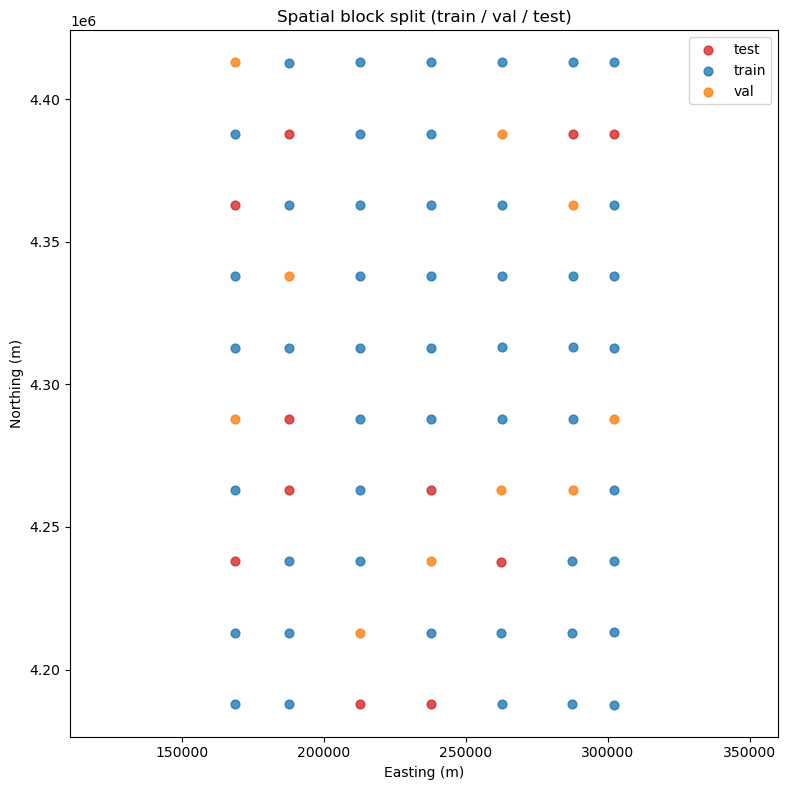

split
test      3925329
train    16572939
val       3445742
Name: n_samples, dtype: int64

In [39]:
# Spatial diagnostiscs
block_df = (
    df.groupby("block_id")
      .agg(
          x_mean=("x", "mean"),
          y_mean=("y", "mean"),
          split=("split", "first"),
          n=("phase", "size")
      )
      .reset_index()
)

import matplotlib.pyplot as plt

colors = {"train": "tab:blue", "val": "tab:orange", "test": "tab:red"}

plt.figure(figsize=(8, 8))
for split, g in block_df.groupby("split"):
    plt.scatter(
        g["x_mean"], g["y_mean"],
        s=40, c=colors[split], label=split, alpha=0.8
    )

plt.legend()
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Spatial block split (train / val / test)")
plt.axis("equal")
plt.tight_layout()
plt.show()

df.groupby("split").size().rename("n_samples")

## Step 5: XGBoost Model Architecture

In [ ]:
FEATURES = [
    "temp_air", "temp_dew", "temp_wet", "rh",
    "imerg_plp",
    "prism_tair", "prism_tmean", "prism_tdmean", "prism_ppt_daily",
    "elev",
]

TARGET = "phase"

# Prepare set matrices
X_train = df.loc[df["split"] == "train", FEATURES]
y_train = df.loc[df["split"] == "train", TARGET]

X_val   = df.loc[df["split"] == "val", FEATURES]
y_val   = df.loc[df["split"] == "val", TARGET]

X_test  = df.loc[df["split"] == "test", FEATURES]
y_test  = df.loc[df["split"] == "test", TARGET]


In [41]:
# Handle class imbalance... compute class weights from training set
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1,2])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.values
)

class_weight = dict(zip(classes, weights))
print("Class weights:", class_weight)

sample_weight_train = y_train.map(class_weight).values
sample_weight_val   = y_val.map(class_weight).values

Class weights: {np.int64(0): np.float64(1.8787061875443805), np.int64(1): np.float64(0.5356439507611696), np.int64(2): np.float64(1.664427971170029)}


### Following sections are in progress...

In [44]:
# Train with XGboost

import xgboost as xgb

params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 1.0,
    "tree_method": "hist",
    "seed": 42,
}


dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weight_train)
dval   = xgb.DMatrix(X_val,   label=y_val,   weight=sample_weight_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# What to look for:
# - Early stopping should trigger well before 2000 trees
# - Validation loss should decrease smoothly
# - If it oscillates wildly → reduce depth or learning rate

evals = [(dtrain, "train"), (dval, "val")]

booster = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=50,
)

# Predict
y_test_prob = booster.predict(dtest)  # shape (n_samples, 3)
y_test_pred = y_test_prob.argmax(axis=1)


[0]	train-mlogloss:1.07758	val-mlogloss:1.07889
[50]	train-mlogloss:0.72404	val-mlogloss:0.74243
[100]	train-mlogloss:0.65362	val-mlogloss:0.67670
[150]	train-mlogloss:0.62047	val-mlogloss:0.64684
[200]	train-mlogloss:0.59898	val-mlogloss:0.62790
[250]	train-mlogloss:0.58452	val-mlogloss:0.61546
[300]	train-mlogloss:0.57253	val-mlogloss:0.60533
[350]	train-mlogloss:0.56229	val-mlogloss:0.59700
[400]	train-mlogloss:0.55304	val-mlogloss:0.58946
[450]	train-mlogloss:0.54455	val-mlogloss:0.58258
[500]	train-mlogloss:0.53718	val-mlogloss:0.57666
[550]	train-mlogloss:0.53003	val-mlogloss:0.57116
[600]	train-mlogloss:0.52384	val-mlogloss:0.56643
[650]	train-mlogloss:0.51803	val-mlogloss:0.56202
[700]	train-mlogloss:0.51208	val-mlogloss:0.55754
[750]	train-mlogloss:0.50709	val-mlogloss:0.55372
[800]	train-mlogloss:0.50220	val-mlogloss:0.55002
[850]	train-mlogloss:0.49726	val-mlogloss:0.54660
[900]	train-mlogloss:0.49264	val-mlogloss:0.54323
[950]	train-mlogloss:0.48806	val-mlogloss:0.53995
[10

### Diagnostics

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_test_pred, labels=[0,1,2])
print(cm)

print(classification_report(
    y_test, y_test_pred,
    target_names=["snow","mix","rain"],
    digits=3
))

In [ ]:
from sklearn.metrics import log_loss

print("Test log loss:", log_loss(y_test, y_test_prob))


In [ ]:
from sklearn.metrics import brier_score_loss

for i, name in enumerate(["snow","mix","rain"]):
    print(
        name,
        brier_score_loss((y_test == i).astype(int), y_test_prob[:, i])
    )


### Uncertainty Diagnostics

In [ ]:
from scipy.stats import entropy

df_test = df.loc[df["split"] == "test"].copy()
df_test["p_snow"] = y_test_prob[:,0]
df_test["p_mix"]  = y_test_prob[:,1]
df_test["p_rain"] = y_test_prob[:,2]

df_test["entropy"] = entropy(
    y_test_prob.T, base=2
)

# High entropy → uncertain phase (often near 0 °C, complex storms)
# Low entropy → confident snow or rain

## Step 6: SHAP analysis